# 02_LSTM_AnomalyDetection (PyTorch)

센서 시계열(Avg Voltage, Avg Current)을 슬라이딩 윈도우로 분할하고 LSTM 이진 분류로 이상탐지.  
**3-Fold Stratified CV**로 하이퍼파라미터 탐색 후 최적 파라미터로 최종 학습.

| 구분 | Trial | Label |
|---|---|---|
| Train+Val (CV 탐색) | Test1~45 | 0=정상, 1=이상 |
| Test (최종 평가) | Val1, Val2, Val5, Val8, Val9 | 0=정상, 1=이상 |

## 정규화 전략: Trial 내 z-score

각 trial의 Avg Current 평균이 라벨과 직결되어 있음 (정상 155~180A, 이상 120~150A).  
Trial별 z-score로 DC 성분을 제거 → trial 내부 변동(fluctuation) 패턴만 학습 신호로 남김.

In [81]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [82]:
from pathlib import Path

# =========================
# 경로 설정
# =========================
BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'lstm_model'
MODEL_DIR.mkdir(exist_ok=True)

# =========================
# 센서 / 윈도우 설정
# =========================
SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES = ['Avg Voltage', 'Avg Current']

# =========================
# 라벨 매핑
# =========================
NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

# =========================
# 학습 / CV 설정
# =========================
EPOCHS              = 200
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42
N_ITER              = 20   # 랜덤 탐색 조합 수
CV_EPOCHS           = 100  # CV fold당 최대 epoch
CV_PATIENCE         = 10   # CV fold early stop patience

print(f'WINDOW_SIZE : {WINDOW_SIZE} samples ({WINDOW_DURATION}s)')
print(f'STEP_SIZE   : {STEP_SIZE} samples ({STEP_DURATION}s)')

WINDOW_SIZE : 30 samples (3.0s)
STEP_SIZE   : 10 samples (1.0s)


In [83]:
import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)

PyTorch : 2.11.0+cu128
Device  : cuda


In [84]:
# =========================
# 유틸: 폴더명 파싱 / 라벨·split 결정
# =========================

def parse_folder_id(folder_name):
    m = re.match(r'^(Test|Val)(\d+)_', folder_name, flags=re.IGNORECASE)
    if not m:
        return None, None
    return m.group(1).capitalize(), int(m.group(2))


def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError(f'라벨 매핑 없음: {prefix}{idx}')


def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError(f'알 수 없는 prefix: {prefix}')


# =========================
# 데이터 로드 (Avg Voltage, Avg Current만 사용)
# Trial 내 z-score로 DC 레벨 제거
# =========================

def load_all_trials(base_dir):
    records = []
    for trial_dir in sorted(base_dir.iterdir()):
        if not trial_dir.is_dir():
            continue
        prefix, idx = parse_folder_id(trial_dir.name)
        if prefix is None:
            continue
        try:
            label = get_label(prefix, idx)
            split = get_split(prefix, idx)
        except ValueError as e:
            print(f'[SKIP] {trial_dir.name}: {e}')
            continue

        csv_files = list(trial_dir.glob('*.csv'))
        if not csv_files:
            print(f'[SKIP] {trial_dir.name}: CSV 없음')
            continue

        df   = pd.read_csv(csv_files[0])[FEATURES].astype(float)
        data = df.values  # (n_rows, 2)

        # Trial 내 z-score (DC 레벨 제거)
        mean = data.mean(axis=0)
        std  = data.std(axis=0)
        std[std < 1e-8] = 1e-8
        data_norm = (data - mean) / std   # (n_rows, 2)

        records.append({
            'folder':   trial_dir.name,
            'prefix':   prefix,
            'id':       idx,
            'label':    label,
            'split':    split,
            'data':     data_norm,
            'raw_mean': mean,
            'raw_std':  std,
        })
        print(f'{trial_dir.name:45s}  split={split:5s}  label={label}'
              f'  rows={len(df)}  μI={mean[1]:.1f}A  σI={std[1]:.2f}')
    return records


records = load_all_trials(BASE_DIR)

summary = pd.DataFrame([{k: r[k] for k in ('folder','split','label')} for r in records])
print('\n=== Split 요약 ===')
print(summary.groupby(['split','label']).size().rename('n_trials'))

Test1_160A_20TS_160WFR                         split=train  label=0  rows=388  μI=156.1A  σI=6.39
Test2_160A_20TS_190WFR                         split=train  label=0  rows=386  μI=156.2A  σI=5.22
Test31_120A_20TS_160WFR                        split=train  label=1  rows=401  μI=117.8A  σI=4.55
Test32_120A_20TS_190WFR                        split=train  label=1  rows=407  μI=117.6A  σI=6.25
Test34_120A_30TS_190WFR                        split=train  label=1  rows=274  μI=116.8A  σI=7.84
Test38_140A_30TS_180WFR                        split=train  label=1  rows=280  μI=136.6A  σI=9.95
Test3_160A_30TS_160WFR                         split=train  label=0  rows=261  μI=156.1A  σI=4.98
Test41_140A_25TS_180WFR                        split=train  label=1  rows=329  μI=136.8A  σI=5.80
Test43_150A_30TS_190WFR                        split=train  label=1  rows=260  μI=146.5A  σI=7.56
Test44_150A_25TS_160WFR                        split=val    label=0  rows=313  μI=146.2A  σI=9.29
Test45_150A_25TS_180

In [85]:
# =========================
# 슬라이딩 윈도우 생성
# =========================

def make_windows(data, window_size, step_size):
    starts = range(0, len(data) - window_size + 1, step_size)
    return np.stack([data[s:s + window_size] for s in starts])


def build_dataset(records, window_size, step_size):
    buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
    test_folders = []

    for r in records:
        wins = make_windows(r['data'], window_size, step_size)
        if len(wins) == 0:
            print(f'[WARNING] {r["folder"]}: 윈도우 0개')
            continue
        labels = np.full(len(wins), r['label'], dtype=np.float32)
        buckets[r['split']][0].append(wins)
        buckets[r['split']][1].append(labels)
        if r['split'] == 'test':
            test_folders.extend([r['folder']] * len(wins))
        print(f'{r["folder"]:45s}  {r["split"]:5s}  windows={len(wins)}')

    X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
    y = {s: np.concatenate(buckets[s][1]) for s in buckets}
    return X, y, np.array(test_folders)


X, y, test_folders = build_dataset(records, WINDOW_SIZE, STEP_SIZE)

print('\n=== 윈도우 개수 ===')
for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):5d}  normal={cnt.get(0,0):5d}  abnormal={cnt.get(1,0):5d}')

Test1_160A_20TS_160WFR                         train  windows=36
Test2_160A_20TS_190WFR                         train  windows=36
Test31_120A_20TS_160WFR                        train  windows=38
Test32_120A_20TS_190WFR                        train  windows=38
Test34_120A_30TS_190WFR                        train  windows=25
Test38_140A_30TS_180WFR                        train  windows=26
Test3_160A_30TS_160WFR                         train  windows=24
Test41_140A_25TS_180WFR                        train  windows=30
Test43_150A_30TS_190WFR                        train  windows=24
Test44_150A_25TS_160WFR                        val    windows=29
Test45_150A_25TS_180WFR                        val    windows=29
Test5_160A_40TS_160WFR                         train  windows=17
Test7_180A_20TS_160WFR                         train  windows=35
Test8_180A_20TS_190WFR                         train  windows=35
Val1_130A_22TS_170WFR                          test   windows=24
Val2_130A_24TS_200WFR    

In [86]:
# =========================
# 글로벌 StandardScaler
# trial z-score 후 피처 간 스케일 조정
# =========================

n_feat = X['train'].shape[2]   # 2 (V, I)
FEAT_NAMES = ['V', 'I']

scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

print('=== 글로벌 스케일러 통계 (train 기준) ===')
for i, name in enumerate(FEAT_NAMES):
    print(f'  {name:5s}  mean={scaler.mean_[i]:+.4f}  std={scaler.scale_[i]:.4f}')

print(f'\nX_train : {Xs["train"].shape}')
print(f'X_val   : {Xs["val"].shape}')
print(f'X_test  : {Xs["test"].shape}')

=== 글로벌 스케일러 통계 (train 기준) ===
  V      mean=+0.0204  std=0.6635
  I      mean=+0.0815  std=0.2982

X_train : (364, 30, 2)
X_val   : (58, 30, 2)
X_test  : (150, 30, 2)


In [87]:
# =========================
# PyTorch Dataset + test DataLoader
# =========================

class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# test_loader는 평가 셀에서 사용 (고정)
test_loader = DataLoader(WindowDataset(Xs['test'], y['test']), batch_size=64, shuffle=False)

# CV 탐색용: train+val 합산
Xs_tv = np.vstack([Xs['train'], Xs['val']])
ys_tv = np.concatenate([y['train'], y['val']]).astype(np.float32)

print(f'Xs_tv  : {Xs_tv.shape}')
print(f'ys_tv  : {ys_tv.shape}  (0={int((ys_tv==0).sum())}, 1={int((ys_tv==1).sum())})')
print(f'X_test : {Xs["test"].shape}')

Xs_tv  : (422, 30, 2)
ys_tv  : (422,)  (0=212, 1=210)
X_test : (150, 30, 2)


In [88]:
# =========================
# LSTM 모델 정의 + 3-Fold Stratified CV 하이퍼파라미터 탐색
# CV fold에서 best_epoch도 기록 → 최종 학습 epoch 수로 사용
# =========================

class LSTMAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x);  out = self.drop1(out)
        out, _ = self.lstm2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


n_feat = Xs_tv.shape[2]   # 2

lstm_param_dist = {
    'hidden1':    [32, 64, 128],
    'hidden2':    [16, 32, 64],
    'dropout':    [0.2, 0.3, 0.5],
    'lr':         [1e-3, 5e-4],
    'batch_size': [16, 32],
}

random.seed(RANDOM_SEED)
sampled_params = [
    {k: random.choice(v) for k, v in lstm_param_dist.items()}
    for _ in range(N_ITER)
]

crit            = nn.BCELoss()
cv_results      = []
best_cv_auc     = -1
best_lstm_params = None

for i, params in enumerate(sampled_params):
    fold_aucs, fold_epochs = [], []

    for fold, (tr_idx, vl_idx) in enumerate(cv3.split(Xs_tv, ys_tv.astype(int))):
        X_tr, X_vl = Xs_tv[tr_idx], Xs_tv[vl_idx]
        y_tr, y_vl = ys_tv[tr_idx], ys_tv[vl_idx]

        mdl = LSTMAnomalyDetector(n_feat, params['hidden1'],
                                   params['hidden2'], params['dropout']).to(DEVICE)
        opt = torch.optim.Adam(mdl.parameters(), lr=params['lr'])
        tr_dl = DataLoader(WindowDataset(X_tr, y_tr), params['batch_size'], shuffle=True)
        vl_dl = DataLoader(WindowDataset(X_vl, y_vl), params['batch_size'])

        best_loss = float('inf'); pc = 0; best_ep = 1
        for ep in range(1, CV_EPOCHS + 1):
            mdl.train()
            for Xb, yb in tr_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); crit(mdl(Xb), yb).backward(); opt.step()
            mdl.eval()
            with torch.no_grad():
                vl_loss = (sum(crit(mdl(Xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                               for Xb, yb in vl_dl) / len(vl_dl.dataset))
            if vl_loss < best_loss:
                best_loss = vl_loss; pc = 0; best_ep = ep
            else:
                pc += 1
                if pc >= CV_PATIENCE: break

        fold_epochs.append(best_ep)

        mdl.eval()
        probs, trues = [], []
        with torch.no_grad():
            for Xb, yb in vl_dl:
                probs.append(mdl(Xb.to(DEVICE)).cpu().numpy())
                trues.append(yb.numpy())
        try:
            auc = roc_auc_score(np.concatenate(trues).astype(int), np.concatenate(probs))
        except Exception:
            auc = 0.5
        fold_aucs.append(auc)

    mean_auc = float(np.mean(fold_aucs))
    avg_ep   = int(round(np.mean(fold_epochs)))
    cv_results.append({'params': params, 'cv_auc': mean_auc,
                       'fold_aucs': fold_aucs, 'fold_epochs': fold_epochs,
                       'avg_epoch': avg_ep})
    print(f'[{i+1:2d}/{N_ITER}] h1={params["hidden1"]:3d} h2={params["hidden2"]:2d} '
          f'drop={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]:2d} '
          f'| CV AUC={mean_auc:.4f}  epochs={fold_epochs}→avg={avg_ep}')

    if mean_auc > best_cv_auc:
        best_cv_auc      = mean_auc
        best_lstm_params = params

best_result     = next(r for r in cv_results if r['params'] == best_lstm_params)
avg_best_epoch  = best_result['avg_epoch']

print(f'\n최적 파라미터  : {best_lstm_params}')
print(f'CV best ROC-AUC: {best_cv_auc:.4f}')
print(f'최종 학습 epoch: {avg_best_epoch}  (CV fold 평균)')

[ 1/20] h1=128 h2=16 drop=0.2 lr=0.0005 bs=16 | CV AUC=0.8488  epochs=[55, 66, 25]→avg=49
[ 2/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | CV AUC=0.7750  epochs=[48, 1, 40]→avg=30
[ 3/20] h1=128 h2=32 drop=0.2 lr=0.001 bs=16 | CV AUC=0.8843  epochs=[33, 26, 45]→avg=35
[ 4/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | CV AUC=0.7672  epochs=[37, 3, 35]→avg=25
[ 5/20] h1=128 h2=64 drop=0.5 lr=0.0005 bs=16 | CV AUC=0.7855  epochs=[27, 2, 48]→avg=26
[ 6/20] h1= 64 h2=64 drop=0.3 lr=0.001 bs=16 | CV AUC=0.8908  epochs=[43, 47, 33]→avg=41
[ 7/20] h1=128 h2=32 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.7744  epochs=[47, 1, 30]→avg=26
[ 8/20] h1= 32 h2=32 drop=0.2 lr=0.001 bs=32 | CV AUC=0.6262  epochs=[2, 1, 46]→avg=16
[ 9/20] h1= 32 h2=32 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.6297  epochs=[2, 6, 50]→avg=19
[10/20] h1=128 h2=32 drop=0.5 lr=0.001 bs=32 | CV AUC=0.7309  epochs=[29, 2, 38]→avg=23
[11/20] h1= 32 h2=64 drop=0.3 lr=0.0005 bs=16 | CV AUC=0.6399  epochs=[1, 2, 30]→avg=11
[12/20] h1=128 h2=16 drop=0

In [89]:
# =========================
# 최적 파라미터로 최종 학습
# epoch 수 = CV fold 평균 best_epoch → early stop 없음
# =========================

model = LSTMAnomalyDetector(n_feat,
                             best_lstm_params['hidden1'],
                             best_lstm_params['hidden2'],
                             best_lstm_params['dropout']).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=best_lstm_params['lr'])
criterion = nn.BCELoss()

final_dl = DataLoader(WindowDataset(Xs_tv, ys_tv),
                       best_lstm_params['batch_size'], shuffle=True)

best_path = str(MODEL_DIR / 'best_lstm.pt')
history   = {'train_loss': []}

print(f'학습 epoch: {avg_best_epoch}  (CV fold 평균)')
for epoch in range(1, avg_best_epoch + 1):
    model.train()
    tr_loss = 0
    for Xb, yb in final_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward(); optimizer.step()
        tr_loss += loss.item() * len(yb)
    tr_loss /= len(final_dl.dataset)
    history['train_loss'].append(tr_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{avg_best_epoch}  train_loss={tr_loss:.4f}')

torch.save(model.state_dict(), best_path)
print(f'\n최종 학습 완료  파라미터: {best_lstm_params}')

학습 epoch: 41  (CV fold 평균)
Epoch   1/41  train_loss=0.6970
Epoch  20/41  train_loss=0.3804
Epoch  40/41  train_loss=0.3154

최종 학습 완료  파라미터: {'hidden1': 64, 'hidden2': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16}


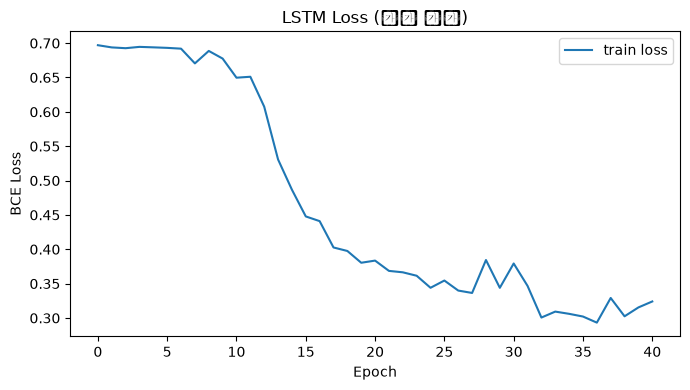

In [90]:
# =========================
# 학습 곡선 (최종 학습 train loss)
# =========================

plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train loss')
plt.title('LSTM Loss (최종 학습)')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.legend(); plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'training_curve.png'), dpi=150)
plt.show()

=== Window-level Evaluation (threshold=0.5) ===
              precision    recall  f1-score   support

   Normal(0)       0.65      0.97      0.78        95
 Abnormal(1)       0.67      0.11      0.19        55

    accuracy                           0.65       150
   macro avg       0.66      0.54      0.48       150
weighted avg       0.66      0.65      0.56       150

ROC-AUC : 0.5589
PR-AUC  : 0.4541


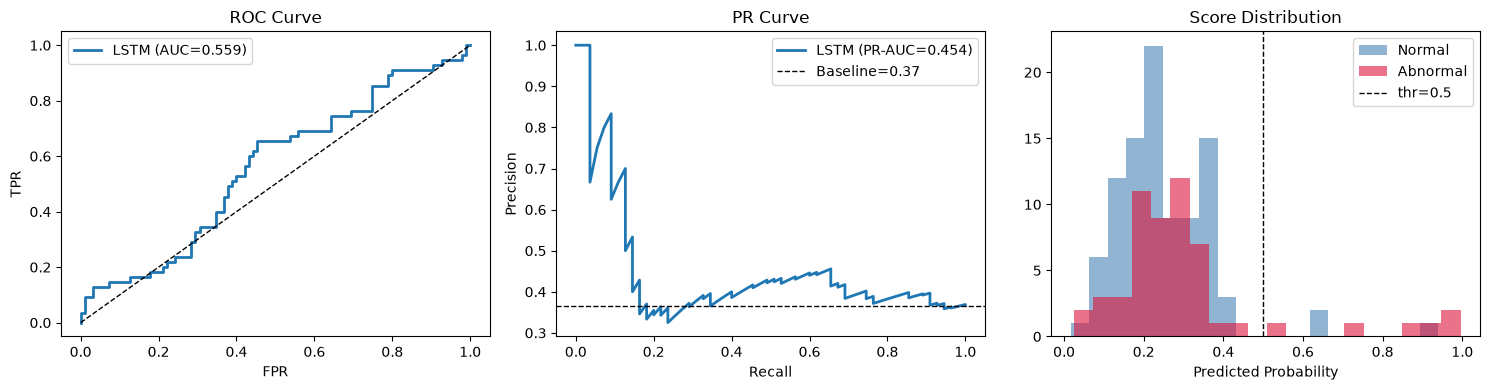

In [91]:
# =========================
# Window-level 평가 (threshold=0.5 고정)
# =========================

model.eval()
all_prob, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        prob = model(X_batch.to(DEVICE)).cpu().numpy()
        all_prob.append(prob)
        all_true.append(y_batch.numpy())

y_prob = np.concatenate(all_prob)
y_true = np.concatenate(all_true).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

print('=== Window-level Evaluation (threshold=0.5) ===')
print(classification_report(y_true, y_pred,
                             target_names=['Normal(0)', 'Abnormal(1)'],
                             zero_division=0))
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'LSTM (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

# PR
pre, rec, _ = precision_recall_curve(y_true, y_prob)
baseline = y_true.mean()
axes[1].plot(rec, pre, lw=2, label=f'LSTM (PR-AUC={pr_auc:.3f})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

# Score distribution
axes[2].hist(y_prob[y_true==0], bins=20, alpha=0.6, label='Normal',   color='steelblue')
axes[2].hist(y_prob[y_true==1], bins=20, alpha=0.6, label='Abnormal', color='crimson')
axes[2].axvline(0.5, color='k', linestyle='--', lw=1, label='thr=0.5')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Score Distribution'); axes[2].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'window_eval.png'), dpi=150)
plt.show()